### Análisis de datos II
# Clase 1 - Interpretabilidad global

### Clasificación multiclase

Vamos a trabajar con el dataset de Penguins y un problema de clasificación, que consiste en predecir la especie del pingüino.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación y entrenamiento ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Interpretabilidad -------------------------------------
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence

from alibi.explainers import ALE
from alibi.explainers import plot_ale

## Dataset

In [2]:
# Dataset
penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


### Entrenamos un modelo de regresión logística

In [3]:
# Variables predictoras y target
X = penguins.copy()
target = "species"

X = penguins.drop(columns=target)
y = penguins[target]

# Columnas categóricas y numéricas
categorical_features = ["island", "sex"]
numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

In [4]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# Transformación
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

feature_names_clean = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor.get_feature_names_out()
]

In [5]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train_trans, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [6]:
coef = model.named_steps["classifier"].coef_

pd.DataFrame(
    coef,
    columns=feature_names_clean,
    index=model.classes_ # multiclase
    # index=[model.classes_[1]] # clasif. binaria
)

,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Adelie,0.063050,-0.324719,0.384220,-0.368763,0.368763,-2.292958,0.925342,-0.682557,-0.183478
Chinstrap,-0.726547,0.897679,-0.224757,0.298319,-0.298319,1.858358,0.091294,-0.181571,-0.629669
Gentoo,0.663497,-0.572960,-0.159463,0.070444,-0.070444,0.434600,-1.016637,0.864128,0.813147


In [7]:
y_pred = model.predict(X_test_trans)

**Calculamos el accuracy y la matriz de confusión para ver cómo anduvo el modelo.**

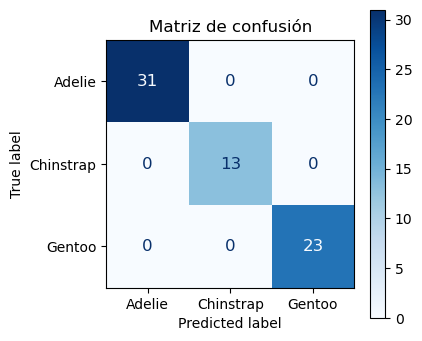


Accuracy: 1.0000


In [8]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap="Blues",
    text_kw={"fontsize": 12}
)
ax.set_title("Matriz de confusión")
plt.show()

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

---
### Permutation Feature Importance (PFI)

In [9]:
model_pfi = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [10]:
result = permutation_importance(
    model_pfi,
    X_test,
    y_test,
    scoring="accuracy",
    n_repeats=10,
    random_state=42
)

In [11]:
pfi = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

pfi = pfi.sort_values("importance", ascending=False)

pfi

,feature,importance,std
1,bill_length_mm,0.271642,0.041577
0,island,0.129851,0.030624
2,bill_depth_mm,0.019403,0.011657
3,flipper_length_mm,0.001493,0.004478
5,sex,0.001493,0.004478
4,body_mass_g,0.000000,0.000000


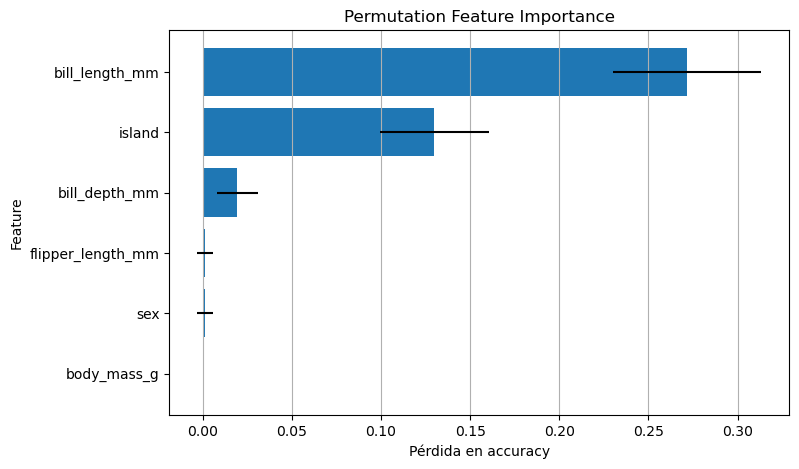

In [12]:
plt.figure(figsize=(8, 5))

plt.barh(
    pfi["feature"],
    pfi["importance"],
    xerr=pfi["std"]
)

plt.xlabel("Pérdida en accuracy")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.show()

---
### Partial Dependence Plot con respecto a la longitud de la aleta

En un problema de clasificación multiclase podemos hacer el PDP sobre la probabilidad de cada una de las clases por separado.

Vamos a analizar cómo cambia la probabilidad predicha de que un pingüino sea de la especie 'Adelie' a medida que varía `bill_length_mm`.

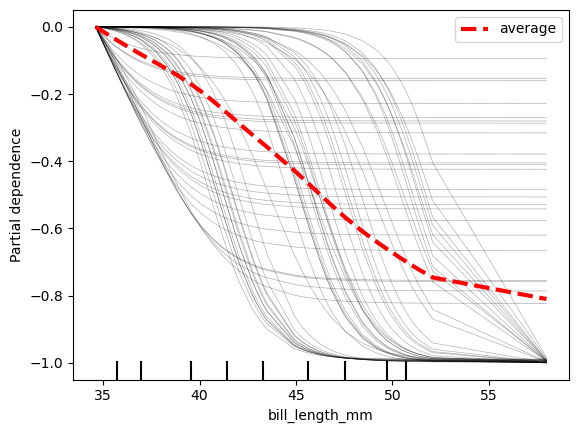

In [13]:
features = ["bill_length_mm"]

PartialDependenceDisplay.from_estimator(
    model,
    X_test_trans,
    kind='both',
    features=features,
    feature_names=feature_names_clean,
    target='Adelie', # Chinstrap, Gentoo
    centered=True,
    ice_lines_kw={"color": "black"},
    pd_line_kw={"color": "red","lw":3,'linestyle':'--'}
)
plt.show()

Podemos analizar cómo cambia la probabilidad predicha de que un pingüino sea de la especie 'Adelie', según las combinaciones de `bill_length_mm` y `flipper_length_mm`.

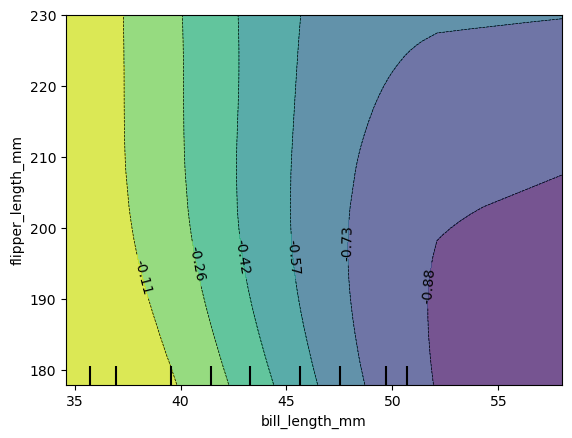

In [14]:
features = [("bill_length_mm", "flipper_length_mm")]

PartialDependenceDisplay.from_estimator(
    model,
    X_test_trans,
    features=features,
    feature_names=feature_names_clean,
    target='Adelie', # Chinstrap, Gentoo
    centered=True)
plt.show()

In [15]:
# Para tener a mano:
# feature_names_clean tiene todos los nombres de las features, en caso que querramos analizar otra combinación.

print(feature_names_clean)

['island_Biscoe', 'island_Dream', 'island_Torgersen', 'sex_Female', 'sex_Male', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


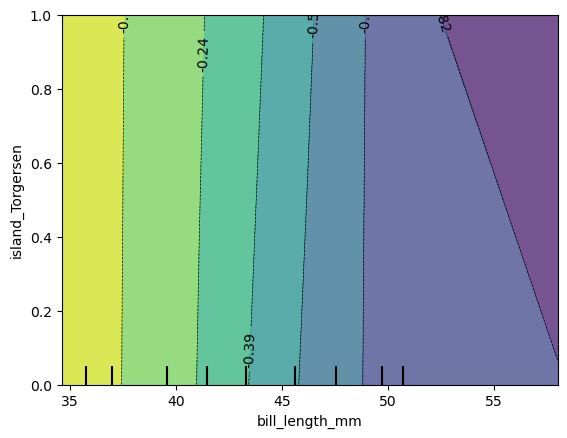

In [16]:
features = [("bill_length_mm", "island_Torgersen")]

PartialDependenceDisplay.from_estimator(
    model,
    X_test_trans,
    features=features,
    feature_names=feature_names_clean,
    target='Adelie',
    centered=True)
plt.show()

---
### ALE

### ALE en el espacio logit

In [17]:
feature_names = X_train.columns.tolist()

def logit_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return model.decision_function(X_trans)

logit_ale = ALE(
    logit_fun,
    feature_names=feature_names,
    target_names=model.classes_
)

logit_exp = logit_ale.explain(
    X_train.to_numpy(),
    features=[1,2,3,4]
)

Veamos cómo varía el efecto de las distintas variables o features según la clase.

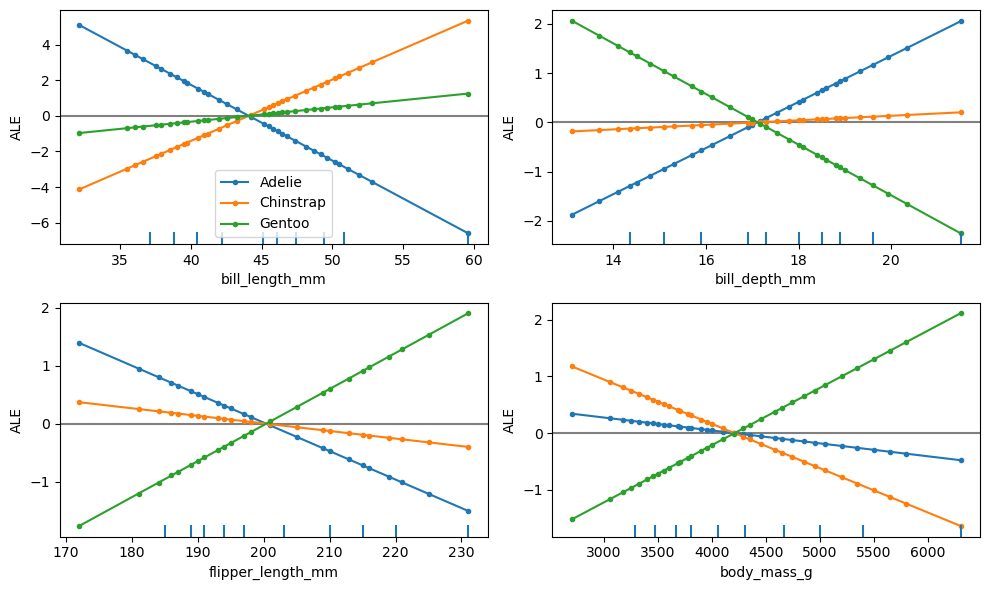

In [18]:
plot_ale(logit_exp, n_cols=2, fig_kw={'figwidth': 10, 'figheight': 6}, sharey=None);

**OBSERVACIONES**:

 - Vemos que los efectos son lineales para todas las clases y para cada feature. Esto es esperable porque la regresión logística es un modelo lineal.
 - La pendiente de cada curva ALE determina el efecto relativo (en logits) de la feature en la predición de cada clase.
 - En particular, la longitud del pico `bill_length_mm` tienen poca variación relativa en su efecto hacia la clase `Gentoo`.
 - Por otro lado, para las clases `Adelie` y `Chinstrap` las pendientes de las curvas son significativas. El efecto relativo sube o baja a medida que el valor de la feature crece.
 - El efecto de la feature en las clases `Adelie` y `Chinstrap` está inversamente relacionado. Esto sugiere que el efecto de picos más largos contribuye más positivamente a predecir `Chinstrap` y negativamente a predecir `Adelie`.

### ALE en el espacio de probabilidades

¿Cómo cambia la probabilidad predicha de cada clase cuando cambia la variable?

In [19]:
model.classes_

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [20]:
def proba_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    # return model.predict_proba(X_trans)[:, 0] # una clase específica
    return model.predict_proba(X_trans) # todas las clases

proba_ale = ALE(
    proba_fun,
    feature_names=feature_names,
    target_names=model.classes_
)

proba_exp = proba_ale.explain(
    X_train.to_numpy(),
    features=[1, 2, 3, 4]
)

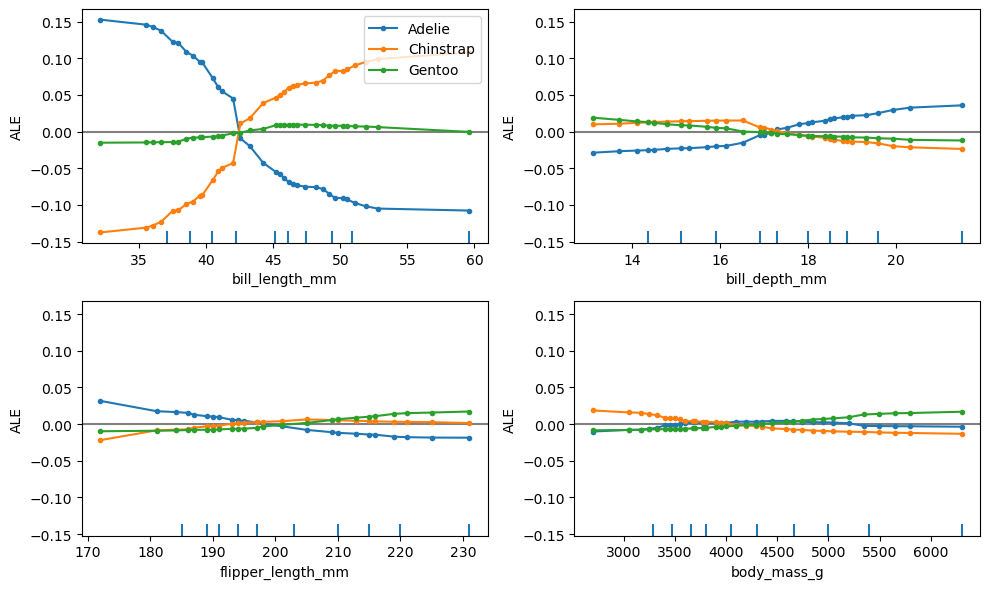

In [21]:
plot_ale(proba_exp, n_cols=2, fig_kw={'figwidth': 10, 'figheight': 6});

**OBSERVACIONES**

La curva ALE para la feature `flipper_length_mm` y la clase `Adelie` es prácticamente plana. Esto significa que el modelo no usa esta feature para asignar más (o menos) probabilidad a la clase `Adelie` con respecto al efecto promedio de la feature. Esto en el espacio logit no se ve.

Aún cuando la curva ALE en el espacio logit muestra un efecto negativo, este no es suficientemente significativo para trasladarlo al espacio de probabilidades.

---
### Entrenamos un Gradient Boosting

Vamos a entrenar y ver los resultados de ALE para un modelo no lineal: Gradient Boosting.

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

In [23]:
gb = GradientBoostingClassifier()
gb.fit(X_train_trans, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [24]:
y_pred = gb.predict(X_test_trans)

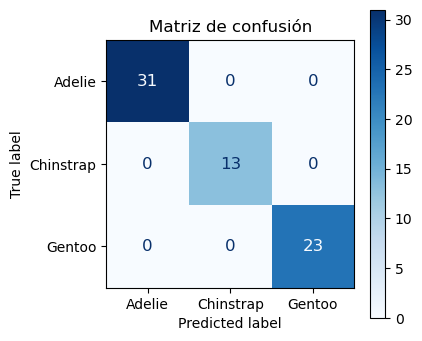


Accuracy: 1.0000


In [25]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap="Blues",
    text_kw={"fontsize": 12}
)
ax.set_title("Matriz de confusión")
plt.show()

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

## ALE

Explicamos las contribuciones de las features, tanto en el espacio logit como en el de probabilidades.

In [26]:
def logit_fun_gb(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return gb.decision_function(X_trans)

def proba_fun_gb(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return gb.predict_proba(X_trans)

In [27]:
logit_ale_gb = ALE(logit_fun_gb, feature_names=feature_names, target_names=gb.classes_)
proba_ale_gb = ALE(proba_fun_gb, feature_names=feature_names, target_names=gb.classes_)

In [28]:
def logit_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return model.decision_function(X_trans)

def proba_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return model.predict_proba(X_trans)

In [29]:
logit_exp_gb = logit_ale_gb.explain(X_train.to_numpy(), features=[1, 2, 3, 4])
proba_exp_gb = proba_ale_gb.explain(X_train.to_numpy(), features=[1, 2, 3, 4])

### ALE en el espacio logit

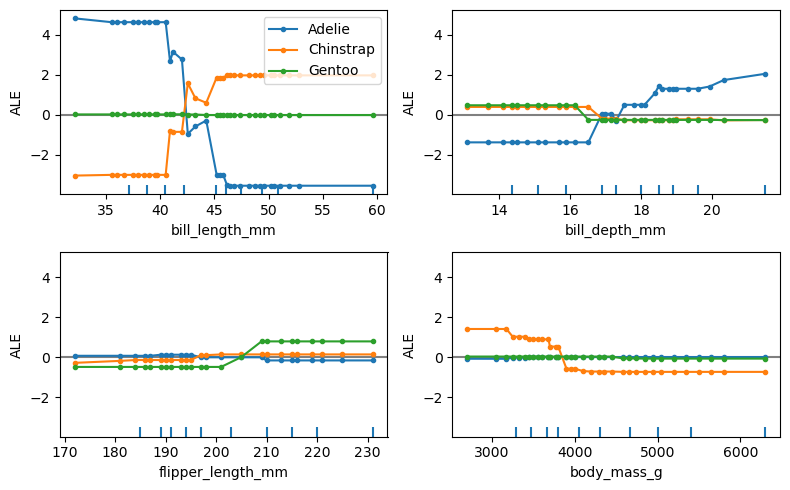

In [30]:
plot_ale(logit_exp_gb, n_cols=2, fig_kw={'figwidth': 8, 'figheight': 5});

Las curvas ALE ya no son lineales, dado que el modelo no es lineal.

Los ALE muestran que `bill_length_mm` y `bill_depth_mm` tienen un efecto importante sobre las predicciones.

### ALE en el espacio de probabilidades

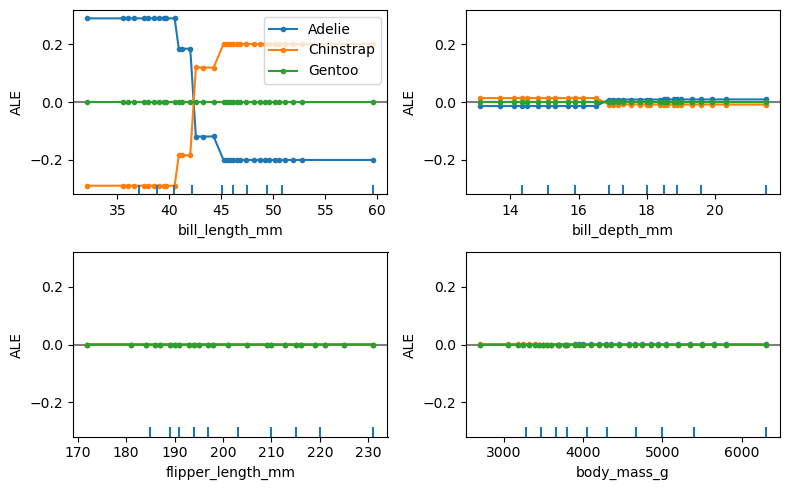

In [31]:
plot_ale(proba_exp_gb, n_cols=2, fig_kw={'figwidth': 8, 'figheight': 5});

### Comparación de ALE entre modelos

¿LR y Gradient Boosting aprenden la misma relación entre las features y la probabilidad de predecir cada una de las clases?

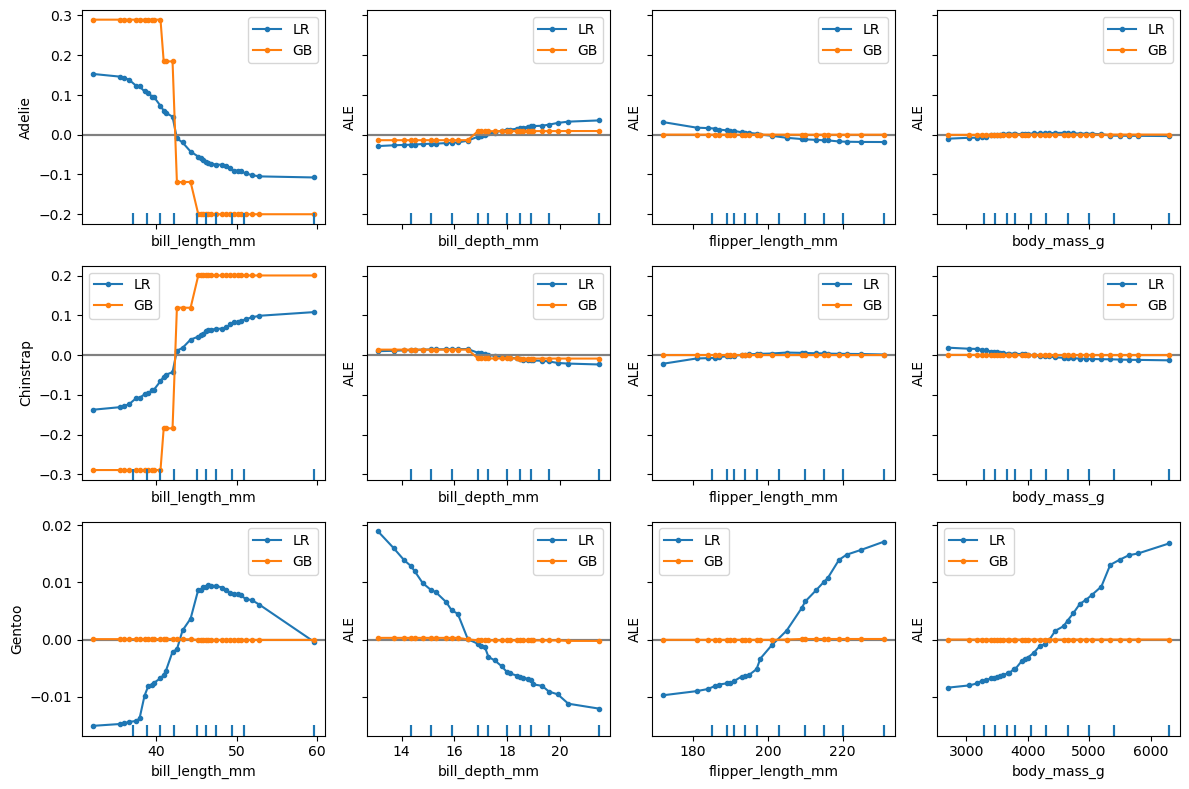

In [32]:
fig, ax = plt.subplots(
    3, 4,
    figsize=(12, 8),
    sharex='col',
    sharey='row'
)

features = [0, 1, 2, 3]
classes = ['Adelie', 'Chinstrap', 'Gentoo']

for i, target in enumerate(classes):
    for j, feature in enumerate(features):

        plot_ale(
            proba_exp,
            features=[feature],
            targets=[target],
            ax=ax[i, j],
            line_kw={'label': 'LR'}
        )

        plot_ale(
            proba_exp_gb,
            features=[feature],
            targets=[target],
            ax=ax[i, j],
            line_kw={'label': 'GB'}
        )

    ax[i, 0].set_ylabel(target)

for j, name in enumerate(feature_names[1:5]):
    ax[2, j].set_xlabel(name)
    
ax[0, 0].legend()
plt.tight_layout()

Cómo interpretamos los plots:
- horizontal: dada una especie (clase), cómo afecta cada una de las features a su predicción
- vertical: dada una feature, como afecta a la predicción de cada una de las tres especies
- LR vs GB: cómo cambia según el modelo.

**CONCLUSIONES**
- En el caso de Adelie y Chinstrap, ambos modelos coinciden en la dirección general para `bill_length_mm` (un pico largo favorece a una especie y castiga a la otra).
- Gradient Boosting parece no usar ninguna de las variables numéricas para predecir la clase Gentoo. Para este modelo, cambiar el valor de estas features no sube ni baja la probabilidad de que el pingüino sea un Gentoo. Probablemente el modelo ya aprendió a identificar a los Gentoo usando otras variables.


---
###  Permutation Feature Importance vs Feature Importance

PFI **NO ES LO MISMO** que `feature_importances_`.

In [33]:
pfi[['feature','importance']]

,feature,importance
1,bill_length_mm,0.271642
0,island,0.129851
2,bill_depth_mm,0.019403
3,flipper_length_mm,0.001493
5,sex,0.001493
4,body_mass_g,0.000000


In [34]:
fi = (
    pd.DataFrame({
        "feature": feature_names_clean,
        "importance": gb.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
fi[:5]

,feature,importance
0,bill_length_mm,0.459100
1,flipper_length_mm,0.322929
2,island_Dream,0.115051
3,bill_depth_mm,0.036131
4,island_Biscoe,0.032848


**Por qué difiere el orden de las features**

`bill_length_mm` es tan dominante en la predicción de la especie, que destaca en ambas: en el PFI y en el ranking de `feature importance`.

El resto de las features difieren en el ranking porque PFI y `feature_importances_` **son medidas de importancia distintas**:
- PFI: Importancia basada en el *desempeño*. Mide cuánto empeora el rendimiento del modelo cuando se destruye la información de una feature.
- feature_importances_: Importancia interna del *modelo*. Mide cuánta reducción total de impureza aportaron los splits que utilizan cada feature en la construcción de los árboles.

Una misma feature puede tener rankings diferentes según cómo definamos “importancia”.